<a href="https://colab.research.google.com/github/SaadH-077/geoverdict/blob/main/notebooks/05_verdicts_evidence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — The verdict: risk fusion and audit-ready evidence

**Question this notebook answers:** given everything the pipeline now knows
about each plot — geometry audit, two forest baselines, a breakpoint
detector, a calibrated CNN — what is the *defensible* risk verdict, and what
does the auditor-facing evidence for it look like?

**Why the fusion is rules, not another model.** Two reasons, one statistical
and one institutional. Statistical: there is no labelled dataset of
adjudicated EUDR outcomes to learn a fusion from — a learned combiner would
be trained on proxies of proxies. Institutional: a due-diligence decision
must survive an auditor asking *why*. "HIGH because: forest at cutoff on
both baselines; NBR breakpoint 2022-07 confirmed by 4 observations; CNN
p=0.94" survives that question. "HIGH because an ensemble said 0.83" does
not. So the machine learning lives in the *evidence* (detectors, baselines,
calibration) and the *fusion* stays transparent — which mirrors how
production compliance systems are actually structured.

**The four tiers** (full logic in `geoverdict/risk.py`, unit-tested):
- **LOW** — analysable, and no credible post-cutoff deforestation signal
  (including: was simply not forest at the cutoff — clearing pasture is not
  deforestation under EUDR).
- **MEDIUM** — analysable, but the evidence conflicts (maps disagree on the
  baseline; detectors disagree with each other) or confidence is degraded.
- **HIGH** — forest at cutoff *and* a corroborated post-cutoff clearing.
- **INSUFFICIENT_EVIDENCE** — the pipeline *admits ignorance*: unrepaired
  geometry, too few cloud-free observations to honestly say "no change", or a
  plot that was **never time-series screened** (here, one outside the 200-plot
  detector subset). This tier is the most important design decision in the file:
  a silent LOW on a plot we never actually *checked* is how non-compliant beef
  gets certified. Note the consequence below — because only a subset was
  screened for runtime, the pipeline correctly **abstains** on the rest rather
  than certifying them unseen. In production every plot is screened and this
  tier shrinks to the genuinely unobservable ones.

**Produces**
- `outputs/verdicts.csv`, `outputs/evidence/plot_*.json`, `outputs/dds_summary.json`
- `figures/g05_*.png`

**Expected runtime:** ~4 minutes, CPU.

### Environment setup and persistence

On Colab this clones the repository, installs dependencies, and mounts Google
Drive so that **outputs survive the session**. Locally it is a no-op beyond
putting `src/` on the path.

**Why Drive.** A Colab VM is deleted when the session ends, and the notebooks
depend on each other's artefacts: 01 writes the validated plot portfolio that
every later chapter loads; 02 writes the forest baselines; 03 the time series;
04 the model predictions. `outputs/`, `figures/` and `evidence/` are therefore
redirected to Drive via environment variables that `geoverdict.config` reads
at import time — which is why they must be set *before* the import.

**Re-running this cell picks up code changes**: it hard-resets the clone to
`origin/main` and purges `geoverdict` from `sys.modules` (Python caches
imports; a `git pull` alone leaves the kernel running the old code). Treat the
clone as read-only — edit code locally and push, not inside `/content`.

In [30]:
# --- edit these if you are running your own fork ---------------------------
GITHUB_USER = "SaadH-077"
USE_DRIVE = True          # False -> everything stays in the ephemeral session
# ---------------------------------------------------------------------------

import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "geoverdict"

if IN_COLAB:
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        PERSIST = Path("/content/drive/MyDrive/geoverdict")
        for sub in ("outputs", "figures", "outputs/evidence"):
            (PERSIST / sub).mkdir(parents=True, exist_ok=True)
        os.environ["GEOVERDICT_OUTPUT_DIR"] = str(PERSIST / "outputs")
        os.environ["GEOVERDICT_FIGURE_DIR"] = str(PERSIST / "figures")
        os.environ["GEOVERDICT_EVIDENCE_DIR"] = str(PERSIST / "outputs" / "evidence")
        print("persisting outputs and figures to", PERSIST)

    if not Path(REPO).exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        f"https://github.com/{GITHUB_USER}/{REPO}.git"], check=False)
    if Path(REPO).exists():
        os.chdir(REPO)
        subprocess.run(["git", "fetch", "--quiet", "--depth", "50", "origin", "main"], check=False)
        before = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
        subprocess.run(["git", "reset", "--hard", "--quiet", "origin/main"], check=False)
        after = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip()
        if before != after:
            print(f"repo updated {before[:7]} -> {after[:7]}")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    except subprocess.CalledProcessError as exc:
        print("!! dependency install failed:", exc)
        print("!! continuing anyway - the cells below will report what is missing")

ROOT = Path.cwd() if Path.cwd().name == REPO or (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

# Purge cached geoverdict modules so a repo update takes effect in THIS kernel.
for m in [m for m in list(sys.modules) if m == "geoverdict" or m.startswith("geoverdict.")]:
    del sys.modules[m]

from geoverdict import config as cfg
from geoverdict import viz

cfg.ensure_dirs()
viz.set_style()
print(f"outputs -> {cfg.OUTPUT_DIR}")
print(f"figures -> {cfg.FIGURE_DIR}")
print(f"seed = {cfg.SEED}, AOI = {cfg.AOI_NAME} {cfg.AOI_BBOX}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
persisting outputs and figures to /content/drive/MyDrive/geoverdict
outputs -> /content/drive/MyDrive/geoverdict/outputs
figures -> /content/drive/MyDrive/geoverdict/figures
seed = 77, AOI = novo_progresso_para_brazil (-55.6, -7.4, -55.2, -7.0)


In [31]:
import geopandas as gpd
import numpy as np
import pandas as pd

plots = gpd.read_file(cfg.OUTPUT_DIR / "plots_analysis.geojson")
baseline = pd.read_csv(cfg.OUTPUT_DIR / "baseline.csv", dtype={"plot_id": str})
detections = pd.read_csv(cfg.OUTPUT_DIR / "ts_detections.csv", dtype={"plot_id": str})
cnn = pd.read_csv(cfg.OUTPUT_DIR / "cnn_predictions.csv", dtype={"plot_id": str})

df = (plots.merge(baseline, on="plot_id", suffixes=("", "_b"))
           .merge(detections, on="plot_id", how="left")
           .merge(cnn[["plot_id", "model_prob"]], on="plot_id", how="left"))
print(f"{len(df)} plots entering the verdict layer")
print(f"  with time-series screening: {df.break_detected.notna().sum()}")
print(f"  with CNN probability:       {df.model_prob.notna().sum()}")

501 plots entering the verdict layer
  with time-series screening: 200
  with CNN probability:       501


Note what the merge just made visible: not every plot has every signal (the
time-series arm screened a stratified subset; chips were lost to cloud for a
few plots). The fusion handles partial evidence *explicitly* — a missing
model probability changes which rule fires, it does not crash a join or
silently default to 0.5. Production pipelines live in this partial-evidence
regime permanently.

In [32]:
from geoverdict import risk

verdicts = []
for r in df.itertuples():
    v = risk.assess_plot(
        plot_id=r.plot_id,
        geometry_ok=True,   # everything in the analysis set passed chapter 01
        geometry_warnings=[w for w in str(getattr(r, "geometry_warnings", "") or "").split("; ") if w],
        forest_frac_jrc=None if pd.isna(r.forest_frac_jrc) else float(r.forest_frac_jrc),
        forest_frac_hansen=None if pd.isna(r.forest_frac_hansen) else float(r.forest_frac_hansen),
        ts_break_detected=None if pd.isna(r.break_detected) else bool(r.break_detected),
        ts_break_date=None if pd.isna(r.break_date) else str(r.break_date),
        ts_obs_density=None if pd.isna(r.obs_density) else float(r.obs_density),
        model_prob=None if pd.isna(r.model_prob) else float(r.model_prob),
        hansen_loss_post_frac=None if pd.isna(r.hansen_loss_post_frac) else float(r.hansen_loss_post_frac),
    )
    verdicts.append(v)

vdf = pd.DataFrame([{"plot_id": v.plot_id, "tier": v.tier,
                     "reasons": " | ".join(v.reasons)} for v in verdicts])
vdf.to_csv(cfg.OUTPUT_DIR / "verdicts.csv", index=False)
tier_counts = vdf.tier.value_counts()
print(tier_counts)
cfg.append_result({"notebook": "05", "name": "tier_counts",
                   **{k: int(v) for k, v in tier_counts.items()}})

tier
MEDIUM                   205
LOW                      189
INSUFFICIENT_EVIDENCE     96
HIGH                      11
Name: count, dtype: int64


PosixPath('/content/drive/MyDrive/geoverdict/outputs/results.json')

figure saved: /content/drive/MyDrive/geoverdict/figures/g05_verdict_map.png


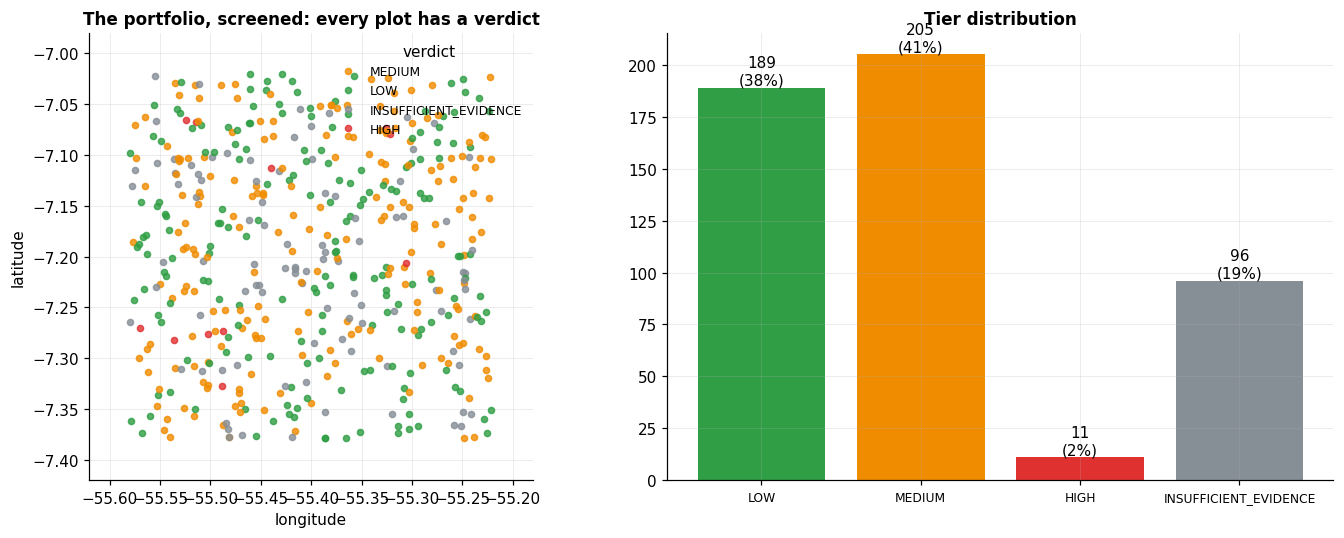

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

geo = plots.set_index("plot_id").geometry
viz.portfolio_map(axes[0], [geo.get(v.plot_id) for v in verdicts],
                  [v.tier for v in verdicts], viz.TIER_COLORS, legend_title="verdict")
axes[0].set_title("The portfolio, screened: every plot has a verdict")

order = ["LOW", "MEDIUM", "HIGH", "INSUFFICIENT_EVIDENCE"]
vals = [int(tier_counts.get(t, 0)) for t in order]
axes[1].bar(order, vals, color=[viz.TIER_COLORS[t] for t in order])
for x, v_ in enumerate(vals):
    axes[1].text(x, v_, f"{v_}\n({v_/len(vdf):.0%})", ha="center", va="bottom")
axes[1].set_title("Tier distribution")
axes[1].tick_params(axis="x", labelsize=8)
fig.tight_layout()
viz.save(fig, "g05_verdict_map")
plt.show()

### How every verdict is reached — the decision cascade

The verdict is not a black box: each plot falls through a fixed sequence of
gates, and this diagram shows exactly where the portfolio splits off, with live
counts. Read top to bottom — geometry, then forest-at-cutoff, then *was it even
screened*, then the detector fusion. A plot exits to a tier the moment a gate
decides it; nothing reaches "clean LOW" without passing every check.

figure saved: /content/drive/MyDrive/geoverdict/figures/g05_decision_flow.png


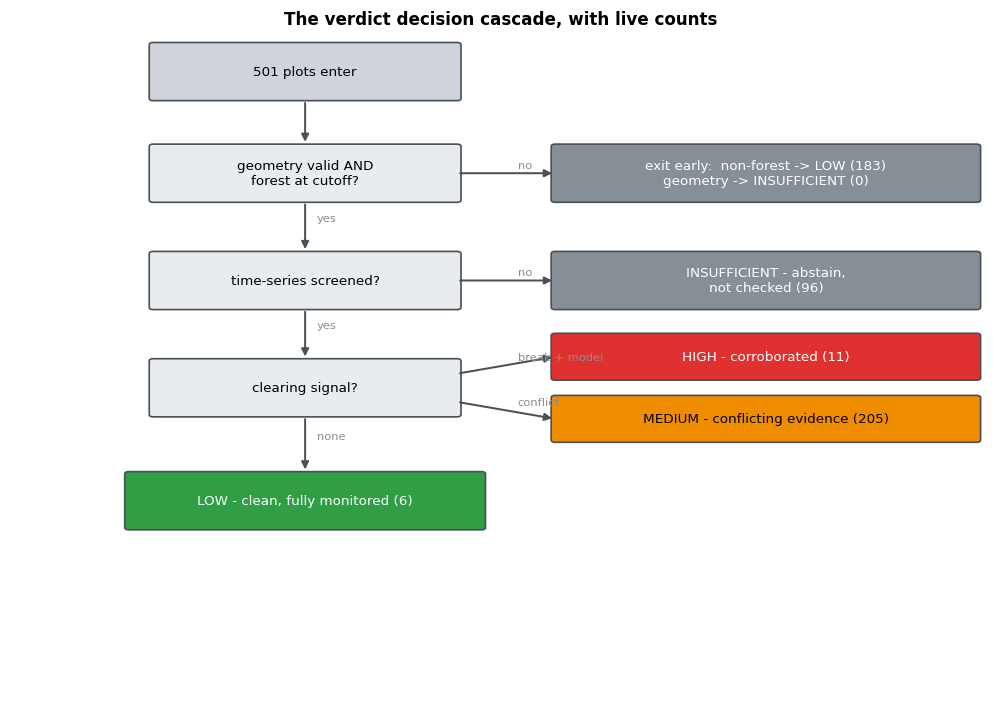

In [34]:
from matplotlib.patches import FancyBboxPatch

R = [" ".join(v.reasons) for v in verdicts]
T = [v.tier for v in verdicts]
def cnt(pred): return sum(1 for r, t in zip(R, T) if pred(r, t))
geom_fail  = cnt(lambda r, t: "geometry could not" in r)
nonforest  = cnt(lambda r, t: "non-forest at the EUDR cutoff" in r)
unscreened = cnt(lambda r, t: "not screened for post-cutoff" in r)
high_n     = sum(1 for t in T if t == "HIGH")
medium_n   = sum(1 for t in T if t == "MEDIUM")
low_clean  = cnt(lambda r, t: "monitored throughout" in r)

fig, ax = plt.subplots(figsize=(11.5, 8)); ax.axis("off")
ax.set_xlim(0, 10); ax.set_ylim(0, 12)
def box(x, y, txt, color="#e9ecef", tc="black", w=3.1, h=0.95):
    ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.04",
                                fc=color, ec="#495057", lw=1.1))
    ax.text(x, y, txt, ha="center", va="center", fontsize=8.8, color=tc)
def arrow(x1, y1, x2, y2, txt="", dx=0.12):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#495057", lw=1.3))
    if txt: ax.text((x1 + x2)/2 + dx, (y1 + y2)/2 + 0.1, txt, fontsize=7.5, color="#868e96")

box(3, 11.2, f"{len(verdicts)} plots enter", color="#ced4da")
box(3, 9.4, "geometry valid AND\nforest at cutoff?")
arrow(3, 10.7, 3, 9.9)
box(7.7, 9.4, f"exit early:  non-forest -> LOW ({nonforest})\ngeometry -> INSUFFICIENT ({geom_fail})",
    color=viz.PALETTE["insufficient"], tc="white", w=4.3)
arrow(4.55, 9.4, 5.55, 9.4, "no")
box(3, 7.5, "time-series screened?")
arrow(3, 8.9, 3, 8.0, "yes")
box(7.7, 7.5, f"INSUFFICIENT - abstain,\nnot checked ({unscreened})",
    color=viz.TIER_COLORS["INSUFFICIENT_EVIDENCE"], tc="white", w=4.3)
arrow(4.55, 7.5, 5.55, 7.5, "no")
box(3, 5.6, "clearing signal?")
arrow(3, 7.0, 3, 6.1, "yes")
box(7.7, 6.15, f"HIGH - corroborated ({high_n})",
    color=viz.TIER_COLORS["HIGH"], tc="white", w=4.3, h=0.75)
arrow(4.55, 5.85, 5.55, 6.15, "break + model")
box(7.7, 5.05, f"MEDIUM - conflicting evidence ({medium_n})",
    color=viz.TIER_COLORS["MEDIUM"], w=4.3, h=0.75)
arrow(4.55, 5.35, 5.55, 5.05, "conflict")
box(3, 3.6, f"LOW - clean, fully monitored ({low_clean})",
    color=viz.TIER_COLORS["LOW"], tc="white", w=3.6)
arrow(3, 5.1, 3, 4.1, "none")
ax.set_title("The verdict decision cascade, with live counts", fontweight="bold", y=0.99)
viz.save(fig, "g05_decision_flow")
plt.show()

### Why did each plot get its tier? Reasons are data, not prose

Every verdict carries machine-readable reasons. Aggregating them turns the
portfolio into an *operations dashboard*: how much MEDIUM comes from
baseline-map disagreement (a data-sourcing problem) vs detector disagreement
(a modelling problem) vs thin observation records (a physics problem)? Each
cause has a different owner and a different fix — this chart is what a team
lead would actually triage from.

figure saved: /content/drive/MyDrive/geoverdict/figures/g05_reason_categories.png


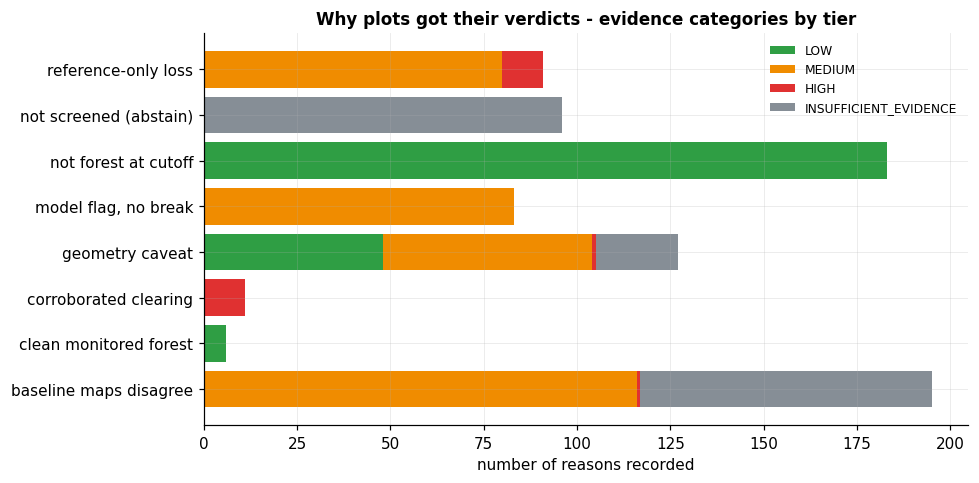

In [35]:
def reason_category(reason: str) -> str:
    if "not screened for post-cutoff" in reason: return "not screened (abstain)"
    if "sustained spectral breakpoint" in reason: return "corroborated clearing"
    if "learned detector flags" in reason: return "model flag, no break"
    if "breakpoint" in reason and "disagrees" in reason: return "detectors disagree"
    if "Hansen maps" in reason: return "reference-only loss"
    if "baselines disagree" in reason: return "baseline maps disagree"
    if "monitoring months" in reason or "record is thin" in reason: return "thin observation record"
    if "non-forest at the EUDR cutoff" in reason: return "not forest at cutoff"
    if "geometry" in reason: return "geometry caveat"
    if "monitored throughout" in reason: return "clean monitored forest"
    return "other"

cats = []
for v in verdicts:
    for reason in v.reasons:
        cats.append({"tier": v.tier, "category": reason_category(reason)})
cat_df = pd.DataFrame(cats)
pivot = cat_df.value_counts(["category", "tier"]).unstack(fill_value=0)[
    [c for c in order if c in cat_df.tier.unique()]]

fig, ax = plt.subplots(figsize=(9, 4.5))
bottom = np.zeros(len(pivot))
for tier in pivot.columns:
    ax.barh(pivot.index, pivot[tier], left=bottom, color=viz.TIER_COLORS[tier], label=tier)
    bottom += pivot[tier].to_numpy()
ax.legend(fontsize=8)
ax.set_title("Why plots got their verdicts - evidence categories by tier")
ax.set_xlabel("number of reasons recorded")
fig.tight_layout()
viz.save(fig, "g05_reason_categories")
plt.show()

### The business translation: what does screening cost?

The tier distribution *is* an analyst workload: every HIGH and MEDIUM (and
arguably every INSUFFICIENT) lands on a human's desk. At an assumed 15
minutes of review per flagged plot, the chart below converts the portfolio
into review-hours — and shows the trade the thresholds are making. This is
the number a deployment discussion actually turns on, and it is also the
frame in which "INSUFFICIENT_EVIDENCE means buy radar data or wait a season"
becomes a costed decision instead of a shrug.

In [36]:
REVIEW_MIN = 15
needs_review = vdf.tier.isin(["HIGH", "MEDIUM", "INSUFFICIENT_EVIDENCE"])
per_1000 = 1000 * needs_review.mean()
hours_per_1000 = per_1000 * REVIEW_MIN / 60

print(f"plots needing human review: {needs_review.sum()}/{len(vdf)} "
      f"= {per_1000:.0f} per 1,000 plots")
print(f"analyst workload at {REVIEW_MIN} min/plot: {hours_per_1000:.0f} h per 1,000 plots screened")
print(f"fully automated (LOW): {(~needs_review).mean():.0%} of the portfolio")

cfg.append_result({"notebook": "05", "name": "screening_cost",
                   "review_per_1000": float(per_1000),
                   "hours_per_1000": float(hours_per_1000),
                   "automated_frac": float((~needs_review).mean())})

plots needing human review: 312/501 = 623 per 1,000 plots
analyst workload at 15 min/plot: 156 h per 1,000 plots screened
fully automated (LOW): 38% of the portfolio


PosixPath('/content/drive/MyDrive/geoverdict/outputs/results.json')

### Evidence bundles: what the auditor opens

For every plot the pipeline emits a JSON bundle — verdict + reasons, the
geometry audit trail, both baseline values, the monthly NDVI/NBR series
*with its gaps preserved* (the months we could not observe are part of the
evidence), the breakpoint, the calibrated model probability, and provenance
down to satellite scene ids and map asset versions. The one-page figure is
the same content made legible in ten seconds.

We render three showcase bundles spanning the interesting tiers: a
corroborated HIGH, a MEDIUM where the official maps disagree, and an
INSUFFICIENT where the honest answer is "the optical record cannot say".

In [37]:
import json
from geoverdict import evidence, timeseries as ts

monthly_df = pd.read_parquet(cfg.OUTPUT_DIR / "series_monthly.parquet")
monthly_df.columns = pd.MultiIndex.from_tuples(
    [tuple(c.split("|")) for c in monthly_df.columns], names=["plot_id", "index"])
prov = [json.loads((cfg.OUTPUT_DIR / "baseline_provenance.json").read_text()),
        {"source": "sentinel-2-l2a via Earth Search STAC + COPERNICUS/S2_SR_HARMONIZED (GEE)",
         "identifiers": ["see chips.npz / series_raw.parquet"],
         "created": "", "parameters": {"chip_bands": list(cfg.CHIP_BANDS)}}]

by_id = {v.plot_id: v for v in verdicts}
screened = set(detections.plot_id) & set(by_id)

# search ALL verdicts for the showcase — INSUFFICIENT plots are unscreened by
# definition, so searching only screened plots would never surface one
def first_where(pred):
    for v in verdicts:
        if pred(v):
            return v.plot_id
    return None

showcase = {
    "high": first_where(lambda v: v.tier == "HIGH"),
    "medium": first_where(lambda v: v.tier == "MEDIUM"),
    "insufficient": first_where(lambda v: v.tier == "INSUFFICIENT_EVIDENCE"),
}
print("showcase plots:", showcase)

# build a bundle for every screened plot AND every plot needing attention (so
# the abstained INSUFFICIENT plots get an evidence record too — their missing
# time-series is shown honestly as absent, which is the whole point)
bundle_ids = sorted(screened | {v.plot_id for v in verdicts if v.tier != "LOW"},
                    key=lambda s: int(s))
plots_ix = plots.set_index("plot_id")
n_saved = 0
for pid in bundle_ids:
    v = by_id[pid]
    ndvi_s = monthly_df[(pid, "ndvi")] if (pid, "ndvi") in monthly_df.columns else None
    nbr_s = monthly_df[(pid, "nbr")] if (pid, "nbr") in monthly_df.columns else None
    br = ts.detect_break(nbr_s, cfg.CUTOFF_DATE).to_dict() if nbr_s is not None else None
    prow = plots_ix.loc[pid]
    bundle = evidence.build_bundle(
        v, {"plot_id": pid, "area_ha": float(prow.area_ha),
            "centroid": [float(prow.geometry.centroid.x), float(prow.geometry.centroid.y)],
            "geometry_status": str(prow.geometry_status),
            "geometry_warnings": str(prow.geometry_warnings or "")},
        ndvi_series=ndvi_s, nbr_series=nbr_s, break_result=br, provenance=prov)
    evidence.save_bundle(bundle)
    n_saved += 1
print(f"saved {n_saved} evidence bundles ({len(screened)} screened + attention-required) "
      f"-> {cfg.EVIDENCE_DIR}")

showcase plots: {'high': '40', 'medium': '0', 'insufficient': '8'}
saved 380 evidence bundles (200 screened + attention-required) -> /content/drive/MyDrive/geoverdict/outputs/evidence


figure saved: /content/drive/MyDrive/geoverdict/figures/g05_evidence_high.png


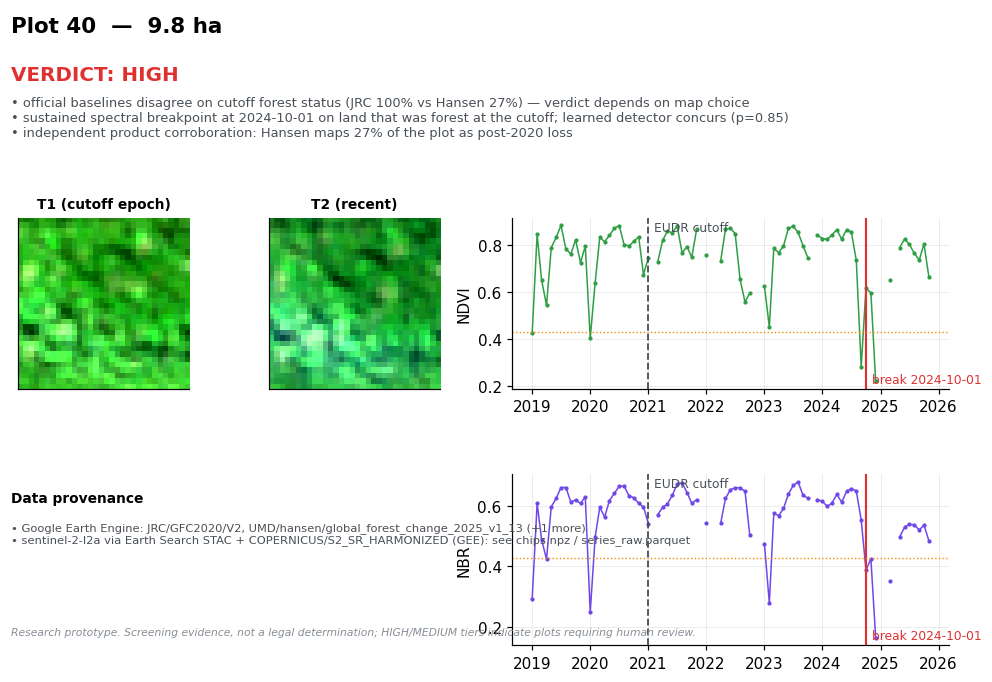

figure saved: /content/drive/MyDrive/geoverdict/figures/g05_evidence_medium.png


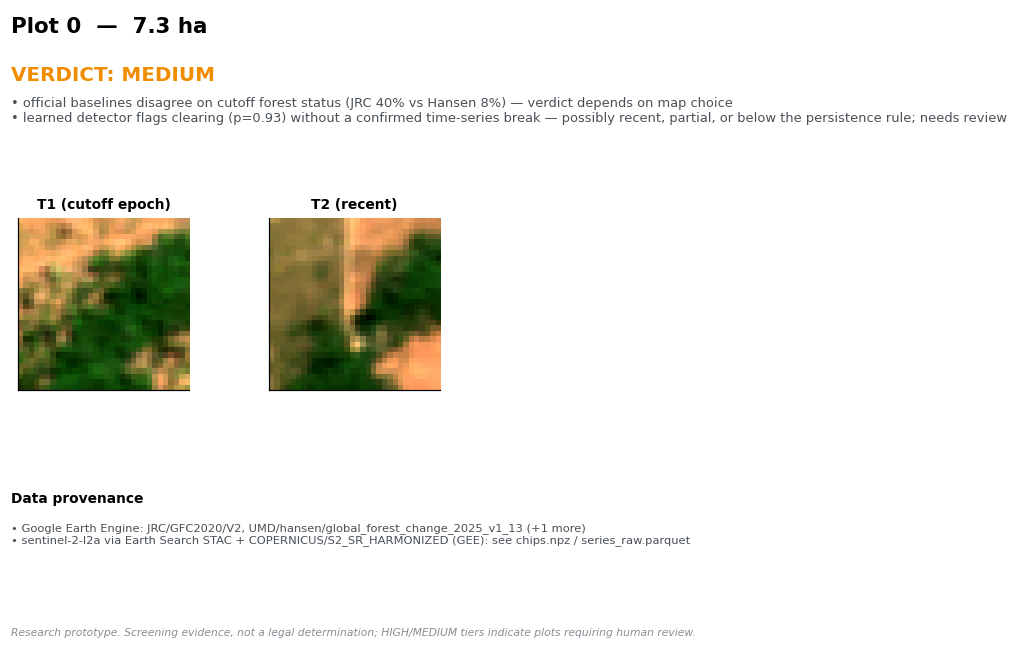

figure saved: /content/drive/MyDrive/geoverdict/figures/g05_evidence_insufficient.png


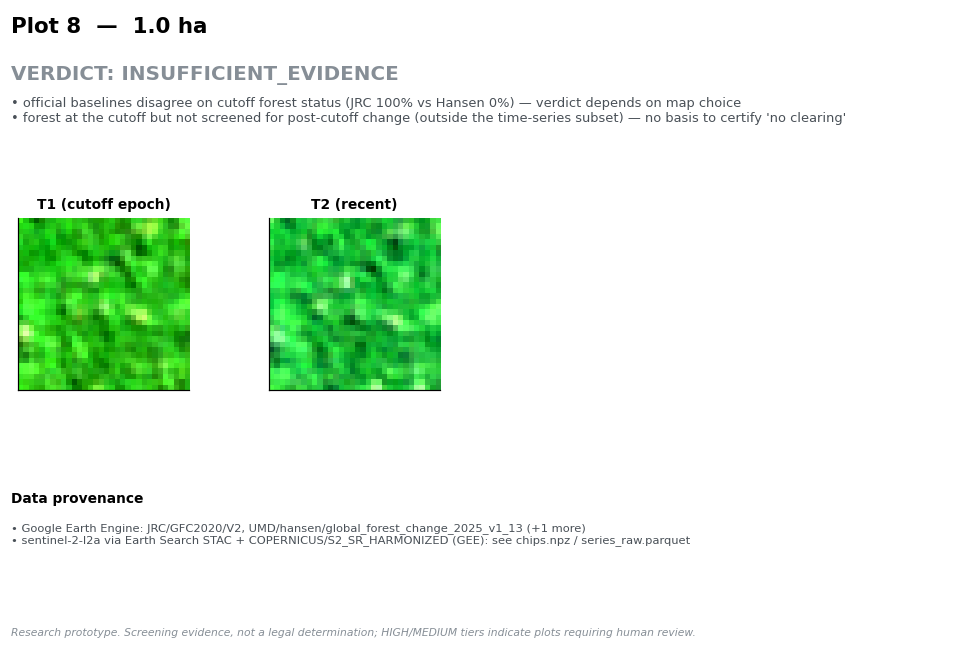

In [38]:
# chips for the showcase figures come from the chapter-04 cache
z = np.load(cfg.OUTPUT_DIR / "chips.npz", allow_pickle=True)
chip_lookup = {s: i for i, s in enumerate(z["sample_id"])}

for name, pid in showcase.items():
    if pid is None:
        continue
    bundle = json.loads((cfg.EVIDENCE_DIR / f"plot_{pid}.json").read_text())
    i = chip_lookup.get(pid)
    fig = viz.evidence_figure(bundle,
                              chip_t1=z["x1"][i] if i is not None else None,
                              chip_t2=z["x2"][i] if i is not None else None)
    viz.save(fig, f"g05_evidence_{name}")
    plt.show()

### The portfolio roll-up: a formatted Due-Diligence screening report

Under EUDR, the operator files a DDS asserting negligible risk *for the
portfolio*, backed by per-plot geolocation and evidence. Below is the shape of
that support, rendered as a clean report a compliance officer would actually
read — a risk overview, the analyst-workload translation, and a ranked table of
the parcels that need a human, each with its leading reason. It is saved to
`outputs/dds_report.md` and the machine-readable roll-up to `dds_summary.json`.

(This is deliberately *support for* a DDS, not a DDS itself: the legal document
carries registry fields — operator identity, HS codes, quantities — out of scope
for a screening prototype, and pretending otherwise would be the kind of
overclaim this project avoids.)

In [39]:
from IPython.display import Markdown, display

# machine-readable roll-up (every non-LOW plot with full reasons)
summary = evidence.portfolio_summary(verdicts, cfg.OUTPUT_DIR / "dds_summary.json")

# human-readable formatted report
areas = dict(zip(plots.plot_id, plots.area_ha))
report_md = evidence.format_dds_report(verdicts, areas)
(cfg.OUTPUT_DIR / "dds_report.md").write_text(report_md, encoding="utf-8")
display(Markdown(report_md))

# EUDR Due Diligence — Screening Summary

**Framework:** EUDR (Regulation (EU) 2023/1115)  ·  **Deforestation cut-off:** 31 December 2020  
**Generated:** 2026-07-23 10:45 UTC  
**Portfolio:** 501 land parcels  ·  3,763 ha total

## Risk overview

| | Tier | Parcels | Share | Assessment |
|:--:|:--|--:|--:|:--|
| 🟥 | **HIGH** | 11 | 2% | corroborated post-2020 clearing on land that was forest at the cutoff |
| ⚠️ | **MEDIUM** | 205 | 41% | conflicting or partial evidence — human review required |
| ◻️ | **INSUFFICIENT** | 96 | 19% | not screened or unobservable — the pipeline abstains |
| ✅ | **LOW** | 189 | 38% | negligible risk — no post-cutoff clearing found |

> **Cleared automatically (LOW):** 189 parcels (38%).  **Require human review:** 312 parcels (62%) — ≈ 156 analyst-hours per 1,000 parcels at 15 min each.

## Parcels requiring attention

| Parcel | Tier | Area (ha) | Leading reason |
|:--|:--|--:|:--|
| 40 | HIGH | 9.8 | sustained spectral breakpoint at 2024-10-01 on land that was forest at the cutof |
| 61 | HIGH | 24.1 | sustained spectral breakpoint at 2024-08-01 on land that was forest at the cutof |
| 100 | HIGH | 6.3 | sustained spectral breakpoint at 2021-08-01 on land that was forest at the cutof |
| 191 | HIGH | 2.7 | sustained spectral breakpoint at 2021-08-01 on land that was forest at the cutof |
| 218 | HIGH | 4.1 | sustained spectral breakpoint at 2022-08-01 on land that was forest at the cutof |
| 288 | HIGH | 3.1 | sustained spectral breakpoint at 2024-09-01 on land that was forest at the cutof |
| 379 | HIGH | 1.3 | sustained spectral breakpoint at 2024-09-01 on land that was forest at the cutof |
| 395 | HIGH | 3.3 | sustained spectral breakpoint at 2021-08-01 on land that was forest at the cutof |
| 411 | HIGH | 6.0 | sustained spectral breakpoint at 2021-08-01 on land that was forest at the cutof |
| 434 | HIGH | 3.8 | sustained spectral breakpoint at 2023-09-01 on land that was forest at the cutof |
| 482 | HIGH | 6.8 | sustained spectral breakpoint at 2024-09-01 on land that was forest at the cutof |
| 0 | MEDIUM | 7.3 | learned detector flags clearing |
| 2 | MEDIUM | 9.3 | Hansen maps 25% of the plot as post-2020 loss but neither in-pipeline detector c |
| 5 | MEDIUM | 21.0 | learned detector flags clearing |
| 13 | MEDIUM | 0.7 | official baselines disagree on cutoff forest status |
| 16 | MEDIUM | 4.3 | geometry warning carried forward: CW_WINDING |
| 20 | MEDIUM | 2.2 | learned detector flags clearing |
| 21 | MEDIUM | 9.5 | Hansen maps 35% of the plot as post-2020 loss but neither in-pipeline detector c |
| 22 | MEDIUM | 2.0 | Hansen maps 65% of the plot as post-2020 loss but neither in-pipeline detector c |
| 23 | MEDIUM | 13.4 | geometry warning carried forward: OVERLAPPING_PLOTS |
| 25 | MEDIUM | 3.8 | learned detector flags clearing |
| 28 | MEDIUM | 4.8 | official baselines disagree on cutoff forest status |
| 30 | MEDIUM | 3.9 | official baselines disagree on cutoff forest status |
| 34 | MEDIUM | 3.5 | official baselines disagree on cutoff forest status |
| 35 | MEDIUM | 5.7 | Hansen maps 39% of the plot as post-2020 loss but neither in-pipeline detector c |
| … | | | *and 287 more — full list in `dds_summary.json`* |

---

*Screening evidence only — not a legal determination. Every HIGH / MEDIUM / INSUFFICIENT parcel above must be resolved by a human before a Due Diligence Statement is signed. Full per-parcel evidence bundles (imagery, spectral time series, provenance) are in `outputs/evidence/`.*

In [40]:
# the attention list as a sortable table (renders cleanly in the notebook)
att = pd.DataFrame([
    {"plot": v.plot_id, "tier": v.tier.replace("_EVIDENCE", ""),
     "area_ha": round(areas.get(v.plot_id, float("nan")), 1),
     "leading_reason": evidence.leading_reason(v)}
    for v in verdicts if v.tier != "LOW"
])
att["_rank"] = att.tier.map({"HIGH": 0, "MEDIUM": 1, "INSUFFICIENT": 2}).fillna(3)
att = (att.sort_values(["_rank", "area_ha"], ascending=[True, False])
          .drop(columns="_rank").reset_index(drop=True))
print(f"{len(att)} parcels require attention (top 15 shown):")
att.head(15)

312 parcels require attention (top 15 shown):


,plot,tier,area_ha,leading_reason
0,61,HIGH,24.1,sustained spectral breakpoint at 2024-08-01 on...
1,40,HIGH,9.8,sustained spectral breakpoint at 2024-10-01 on...
2,482,HIGH,6.8,sustained spectral breakpoint at 2024-09-01 on...
3,100,HIGH,6.3,sustained spectral breakpoint at 2021-08-01 on...
4,411,HIGH,6.0,sustained spectral breakpoint at 2021-08-01 on...
5,218,HIGH,4.1,sustained spectral breakpoint at 2022-08-01 on...
6,434,HIGH,3.8,sustained spectral breakpoint at 2023-09-01 on...
7,395,HIGH,3.3,sustained spectral breakpoint at 2021-08-01 on...
8,288,HIGH,3.1,sustained spectral breakpoint at 2024-09-01 on...
9,191,HIGH,2.7,sustained spectral breakpoint at 2021-08-01 on...


### What this chapter established

1. **The pipeline ends in a decision, with reasons** — every plot carries a
   tier and the evidence trail that produced it; nothing terminates in a bare
   probability.
2. **Partial evidence is handled explicitly, and abstention is honest** —
   a plot that was never time-series screened is *not* quietly certified LOW;
   it is INSUFFICIENT, because "no clearing" is unsupported when nothing looked.
   That single rule is what stops the runtime subset from silently laundering
   unseen plots into "compliant".
3. **INSUFFICIENT_EVIDENCE is a feature** — the share of the portfolio the
   pipeline genuinely cannot certify (unscreened, unobservable, or ungeolocated)
   is now a measured number with a costed remedy (screen the rest, buy radar,
   or wait a season), not a silent LOW.
4. **The evidence bundle is the product**: verdict, series, chips,
   provenance — the artefact a compliance officer, or a court, would open.

**Next and last:** chapter 06 turns on the pipeline's own headlights —
re-verifying every ledger claim, ablating the detector's knobs, quantifying
seed variance, and demonstrating (by doing it wrong on purpose) how much a
random split would have flattered every number in this project.